# Module 4 | Class 2 — Binary Classification: Customer Churn Prediction

**Objective:** Build a logistic regression classifier to predict customer churn, evaluate it with the full suite of classification metrics, and interpret what the model learned.

**Dataset:** Telco Customer Churn (Kaggle)

In [1]:
!pip install kagglehub -q

## Task 1: Prepare the Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Dataset downloaded to:", path)

import os
print(os.listdir(path))

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset downloaded to: /kaggle/input/telco-customer-churn
['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [3]:
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Handle TotalCharges: some rows have blank strings instead of numbers
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


/tmp/ipykernel_1940/131581153.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Encode the target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [5]:
# One-hot encode categorical features (excluding the ID column)
cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), columns=cat_cols, drop_first=True)

print("Encoded shape:", df_encoded.shape)

Encoded shape: (7043, 31)


In [6]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('Train churn rate:', y_train.mean().round(3))
print('Test churn rate:', y_test.mean().round(3))

Train: (5634, 30), Test: (1409, 30)
Train churn rate: 0.265
Test churn rate: 0.265


In [7]:
from sklearn.preprocessing import StandardScaler

# Fit the scaler on TRAIN only, then apply to both train and test (prevents data leakage)
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Task 2: Train a Logistic Regression Model

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Model trained.")

Model trained.


## Task 3: Full Classification Evaluation

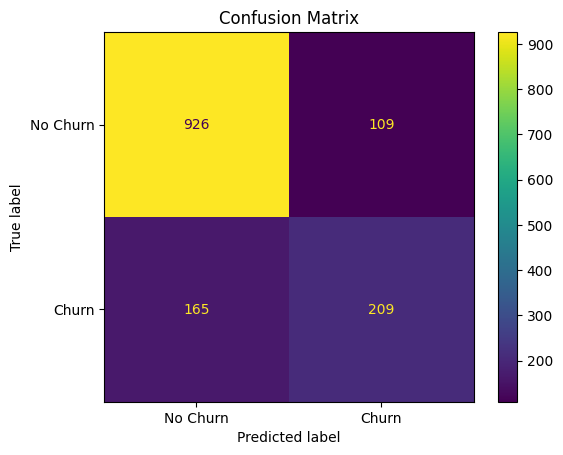

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test, display_labels=['No Churn', 'Churn']
)
plt.title('Confusion Matrix')
plt.show()

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



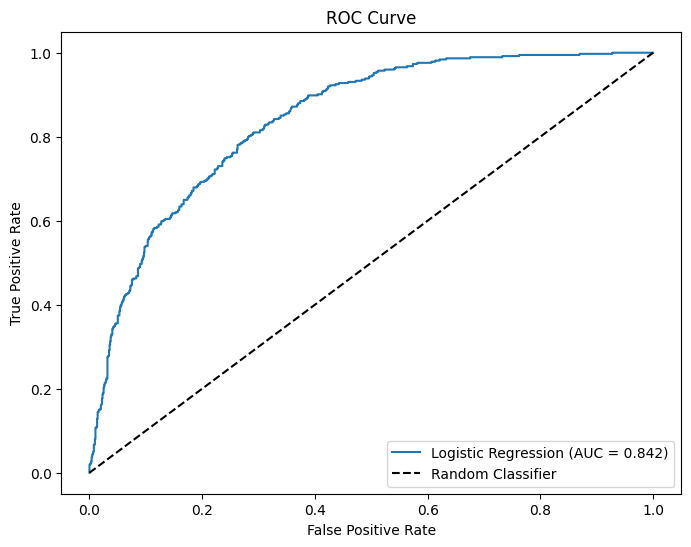

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**Confusion matrix interpretation:**

[After running the confusion matrix above, note the actual numbers in each quadrant.
- **False positives** (predicted Churn, actually stayed) mean the business would spend retention resources (discounts, outreach) on customers who weren't going to leave anyway — a wasted cost.
- **False negatives** (predicted No Churn, actually left) are usually more costly here: these are customers the business failed to flag, so no retention action was taken, and the customer was lost.
- Compare your actual false positive and false negative counts and state which the model makes more of, and what that means for whether the current threshold (0.5 by default) is appropriate.]

*(Replace the bracketed text with your own interpretation based on your actual confusion matrix numbers.)*

## Task 4: Interpret the Model

In [12]:
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

print("Top 5 features associated with CHURN (positive coefficients):")
print(coef_df.head(5))

print("\nTop 5 features associated with RETENTION (negative coefficients):")
print(coef_df.tail(5))

Top 5 features associated with CHURN (positive coefficients):
                           Feature  Coefficient
10     InternetService_Fiber optic     1.190576
3                     TotalCharges     0.511378
23             StreamingMovies_Yes     0.380384
21                 StreamingTV_Yes     0.378872
28  PaymentMethod_Electronic check     0.377641

Top 5 features associated with RETENTION (negative coefficients):
              Feature  Coefficient
2      MonthlyCharges    -0.477810
7    PhoneService_Yes    -0.491306
24  Contract_One year    -0.690863
1              tenure    -1.237578
25  Contract_Two year    -1.337453


**Business sense check:**

[Look at your printed top-5 churn and top-5 retention features. A common, business-plausible pattern in this dataset is that `Contract_Month-to-month` (or the corresponding month-to-month flag) shows a strong positive coefficient — customers without a long-term contract are freer to leave, so this makes intuitive sense. Conversely, features like longer contract length (`Contract_Two year`) or add-on services (`OnlineSecurity_Yes`, `TechSupport_Yes`) often show negative coefficients, suggesting engaged customers with more services or commitments churn less.

Check your actual output against this pattern and write 2-3 sentences confirming or contrasting what your model found.]

*(Replace the bracketed text with your own interpretation based on your actual coefficient output.)*

## Task 5: Threshold Analysis

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.3, 0.5, 0.7]:
    y_pred_t = (y_proba >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    print(f"\nThreshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")

    threshold_results.append({'Threshold': threshold, 'Precision': precision, 'Recall': recall, 'F1': f1})


Threshold: 0.3
Precision: 0.5193
Recall: 0.7540
F1: 0.6150

Threshold: 0.5
Precision: 0.6572
Recall: 0.5588
F1: 0.6040

Threshold: 0.7
Precision: 0.7391
Recall: 0.1818
F1: 0.2918


In [14]:
# Comparison table
threshold_table = pd.DataFrame(threshold_results)
threshold_table

,Threshold,Precision,Recall,F1
0,0.3,0.519337,0.754011,0.615049
1,0.5,0.657233,0.558824,0.604046
2,0.7,0.739130,0.181818,0.291845


**Which threshold to recommend?**

If the business priority is to **catch as many churners as possible** (maximize recall), the **0.3 threshold** is the better choice — lowering the threshold means the model flags more customers as "at risk," catching more true churners, at the cost of more false positives (flagging customers who would have stayed anyway).

The tradeoff: at 0.3, precision drops (more wasted retention spend on customers who wouldn't have churned), but recall rises (fewer actual churners slip through undetected). If the cost of losing a customer is much higher than the cost of an unnecessary retention offer, 0.3 is the right call. If retention offers are expensive and precision matters more, 0.5 or even 0.7 would be preferred instead.

*(Confirm this reasoning against your own actual Precision/Recall/F1 numbers in the table above — the specific values may shift this conclusion.)*

## Summary

- Logistic Regression AUC: see Task 3 ROC curve output
- Top churn driver and top retention driver: see Task 4 output
- Recommended threshold: see Task 5 discussion above, adjusted for actual business priorities